In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", None)

print("Libraries Ready")


Libraries Ready


In [57]:
purchases = pd.read_csv("customer_purchases.csv")
feedback = pd.read_csv("customer_feedback.csv")

display(purchases.head())
display(feedback.head())

,CustomerID,Gender,AgeGroup,Region,ProductCategory,Quantity,Sales
0,1,Male,46-60,North,Grocery,2,84
1,2,Female,26-35,North,Clothing,4,352
2,3,Female,18-25,North,Clothing,3,207
3,4,Male,26-35,West,Grocery,5,125
4,5,Male,18-25,East,Clothing,1,22


,FeedbackID,Channel,Region,Satisfaction
0,1,Online,West,Neutral
1,2,Online,East,Satisfied
2,3,Online,North,Dissatisfied
3,4,Online,West,Neutral
4,5,Online,East,Satisfied


In [58]:
cat_cols = purchases.select_dtypes(include="object").columns.tolist()
print(cat_cols)

num_cols = purchases.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

['Gender', 'AgeGroup', 'Region', 'ProductCategory']
['CustomerID', 'Quantity', 'Sales']


In [59]:
age_order = ["18-25", "26-35", "36-45", "46-60"]
purchases["AgeGroup"] = pd.Categorical(purchases["AgeGroup"], categories = age_order, ordered=True)
purchases["AgeGroup"].head()

0    46-60
1    26-35
2    18-25
3    26-35
4    18-25
Name: AgeGroup, dtype: category
Categories (4, object): ['18-25' < '26-35' < '36-45' < '46-60']

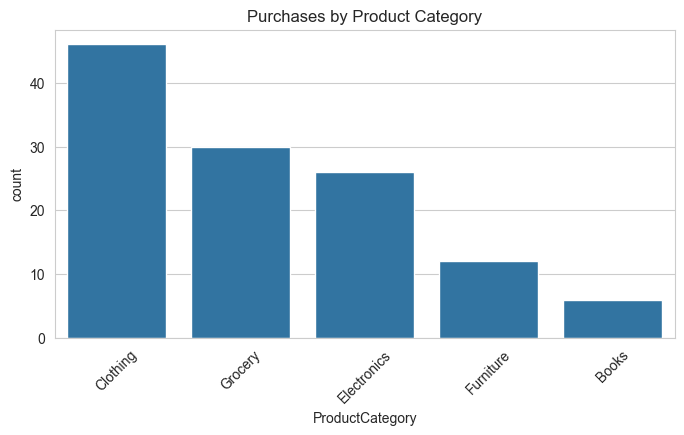

In [60]:
order = purchases["ProductCategory"].value_counts().index # index is the first column
sns.countplot(data = purchases, x = "ProductCategory", order = order)
plt.title("Purchases by Product Category")
plt.xticks(rotation = 45)
plt.show()

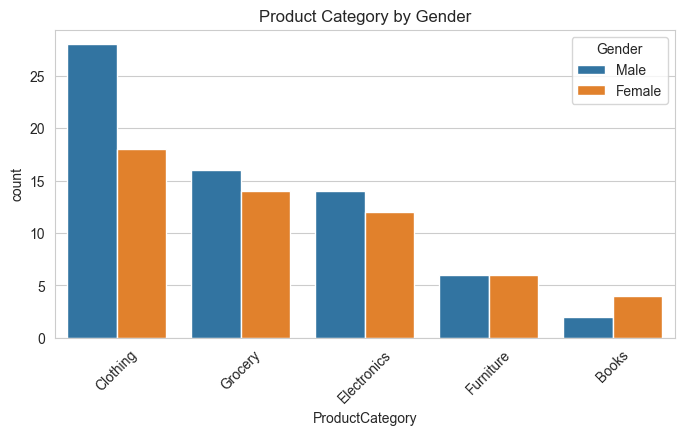

In [61]:
sns.countplot(data = purchases, x = "ProductCategory", hue = "Gender", order = order)
plt.title("Product Category by Gender")
plt.xticks(rotation = 45)
plt.show()

In [62]:
ct = pd.crosstab(purchases["Region"], purchases["ProductCategory"]) # cross tabular table
ct

ProductCategory,Books,Clothing,Electronics,Furniture,Grocery
Region,,,,,
East,1,13,6,2,7
North,1,10,3,2,10
South,2,14,12,7,5
West,2,9,5,1,8


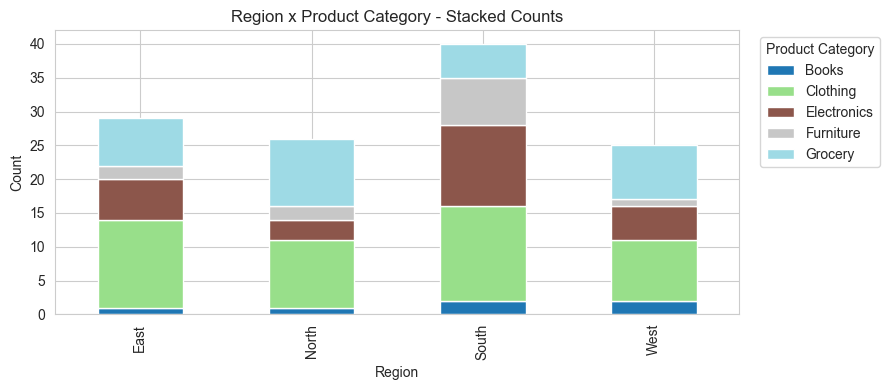

In [63]:
ax = ct.plot(kind = "bar", stacked = True, figsize = (9, 4), colormap = "tab20")
plt.title("Region x Product Category - Stacked Counts")
plt.xlabel("Region")
plt.ylabel("Count")

# upper left = outside of the plot, upper right = inside the plot
# many more locations
plt.legend(bbox_to_anchor = (1.02, 1), loc = "upper left", title = "Product Category") 

plt.tight_layout()
plt.show()

In [64]:
ct_prop = ct.div(ct.sum(axis = 1), axis = 0)
ct_prop

ProductCategory,Books,Clothing,Electronics,Furniture,Grocery
Region,,,,,
East,0.034483,0.448276,0.206897,0.068966,0.241379
North,0.038462,0.384615,0.115385,0.076923,0.384615
South,0.050000,0.350000,0.300000,0.175000,0.125000
West,0.080000,0.360000,0.200000,0.040000,0.320000


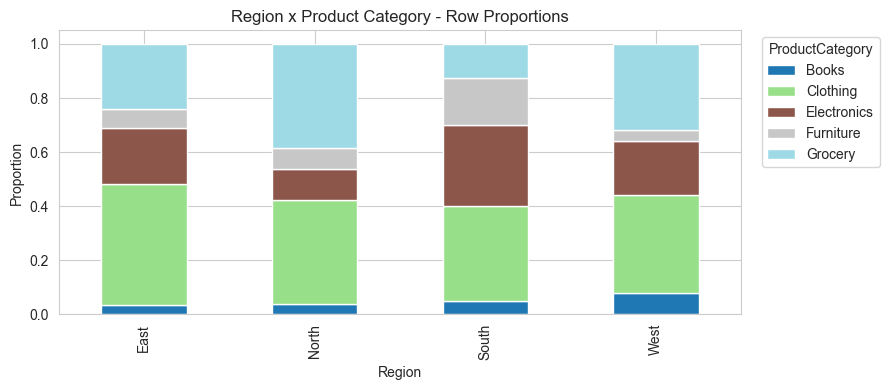

In [65]:
ax = ct_prop.plot(kind = "bar", stacked = True, figsize = (9, 4), colormap = "tab20")
plt.title("Region x Product Category - Row Proportions")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor = (1.02, 1), loc = "upper left", title = "ProductCategory") 
plt.tight_layout()
plt.show()

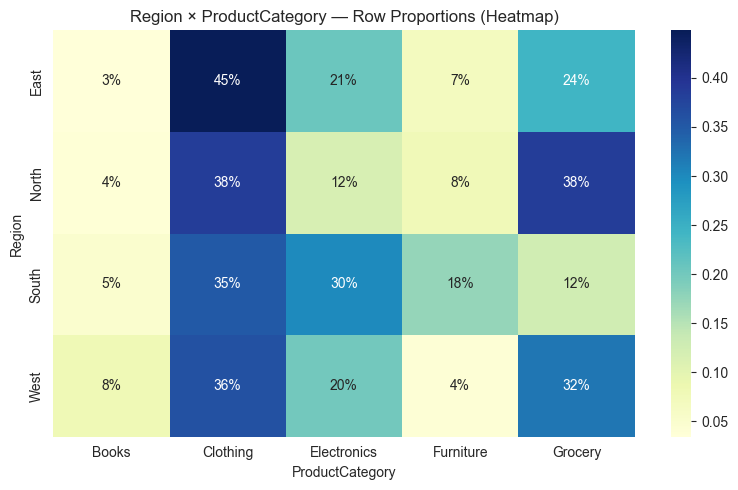

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(ct_prop, annot=True, fmt=".0%", cmap="YlGnBu", cbar=True)
plt.title("Region × ProductCategory — Row Proportions (Heatmap)")
plt.xlabel("ProductCategory"); plt.ylabel("Region")
plt.tight_layout()
plt.show()

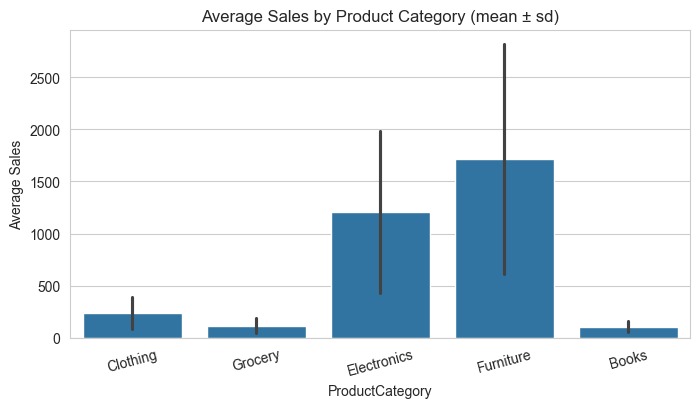

In [67]:
sns.barplot(data=purchases, x="ProductCategory", y="Sales", estimator="mean", errorbar="sd", order=order)
plt.title("Average Sales by Product Category (mean ± sd)")
plt.xticks(rotation=15)
plt.ylabel("Average Sales"); plt.show()

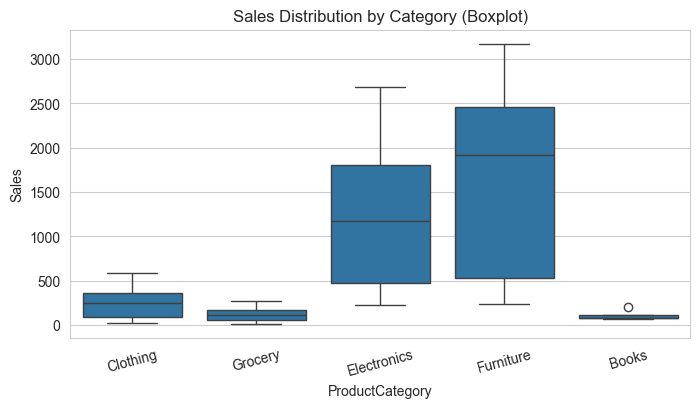

In [68]:
sns.boxplot(data=purchases, x="ProductCategory", y="Sales", order=order)
plt.title("Sales Distribution by Category (Boxplot)")
plt.xticks(rotation=15)
plt.show()

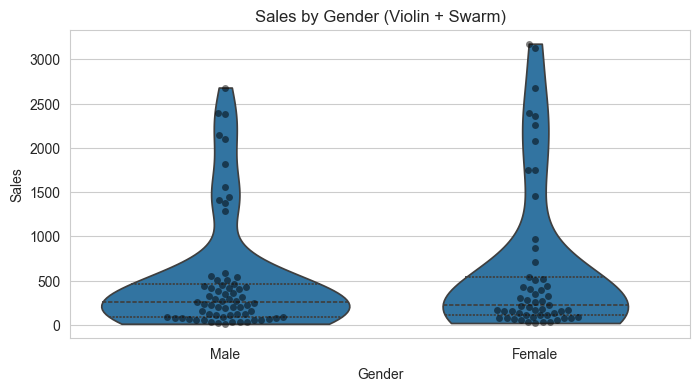

In [69]:
sns.violinplot(data=purchases, x="Gender", y="Sales", inner="quartile", cut=0) # the outer shape
sns.swarmplot(data=purchases, x="Gender", y="Sales", color="black", alpha=0.5) # the dot
plt.title("Sales by Gender (Violin + Swarm)"); plt.show()

/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_55989/1954358635.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  for ax in g.axes.flat: ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_55989/1954358635.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  for ax in g.axes.flat: ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_55989/1954358635.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  for ax in g.axes.flat: ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
/var/folders/k2/09c8j5sd6bbf32rnpwj0kk600000gn/T/ipykernel_55989/1954358635.py:4: UserWarning: set_ticklabels() should only be used w

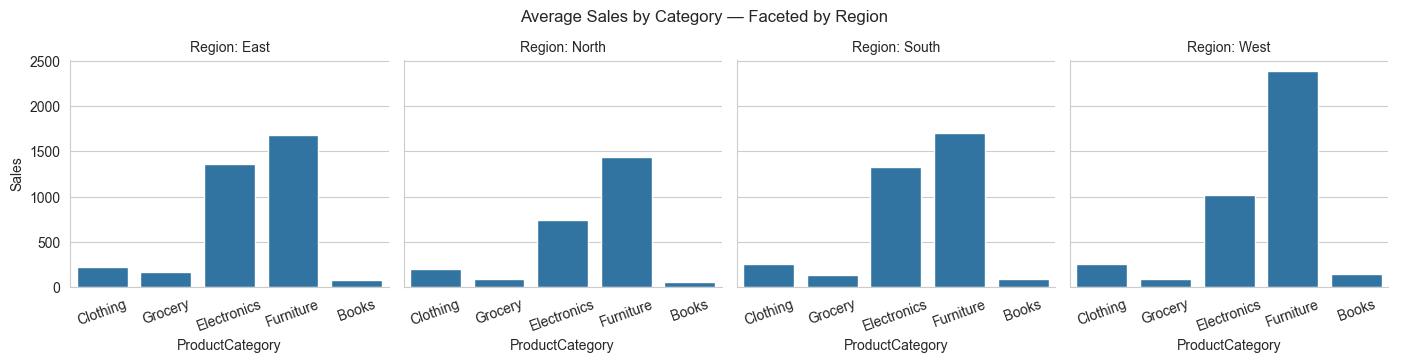

In [70]:
avg_sales = purchases.groupby(["Region","ProductCategory"], as_index=False)["Sales"].mean()
g = sns.catplot(data=avg_sales, x="ProductCategory", y="Sales", col="Region", kind="bar", height=3.2, aspect=1.1, order=order)
g.set_titles("Region: {col_name}")
for ax in g.axes.flat: ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
g.fig.suptitle("Average Sales by Category — Faceted by Region", y=1.05); plt.show()

In [71]:
# adds percentage labels

def add_pct_labels(ax, is_stacked_proportion=False, min_visible=0.05, fmt="{:.0%}"):
    if is_stacked_proportion:
        for container in ax.containers:
            vals = container.datavalues
            labels = [fmt.format(v) if v >= min_visible else "" for v in vals]
            ax.bar_label(container, labels=labels, label_type="center", fontsize=9)
    else:
        total = sum([p.get_height() for p in ax.patches])
        for p in ax.patches:
            h = p.get_height()
            if total > 0:
                ax.annotate("{:.0%}".format(h/total),
                            (p.get_x() + p.get_width()/2., h),
                            ha="center", va="bottom", fontsize=9, xytext=(0,3), textcoords="offset points")


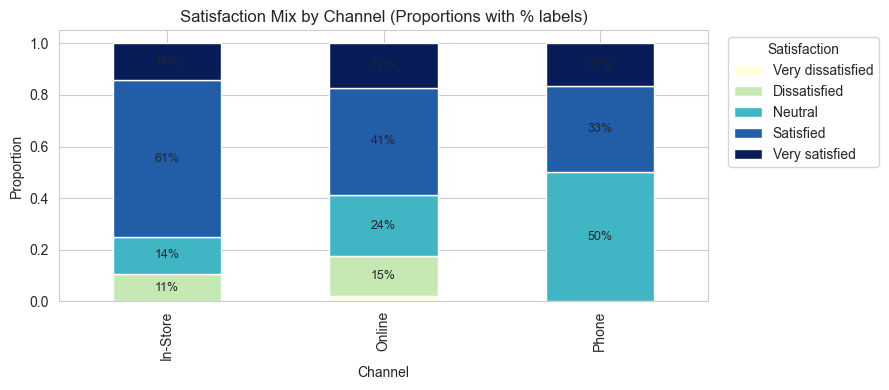

In [ ]:
feedback["Satisfaction"] = pd.Categorical(
    feedback["Satisfaction"],
    categories=["Very dissatisfied","Dissatisfied","Neutral","Satisfied","Very satisfied"],
    ordered=True
)
sat = pd.crosstab(feedback["Channel"], feedback["Satisfaction"])
sat_prop = sat.div(sat.sum(axis=1), axis=0)

ax = sat_prop.plot(kind="bar", stacked=True, figsize=(9,4), colormap="YlGnBu")
add_pct_labels(ax, is_stacked_proportion=True, min_visible=0.08) # adds a label to each category
plt.title("Satisfaction Mix by Channel (Proportions with % labels)")
plt.ylabel("Proportion")
plt.legend(title="Satisfaction", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

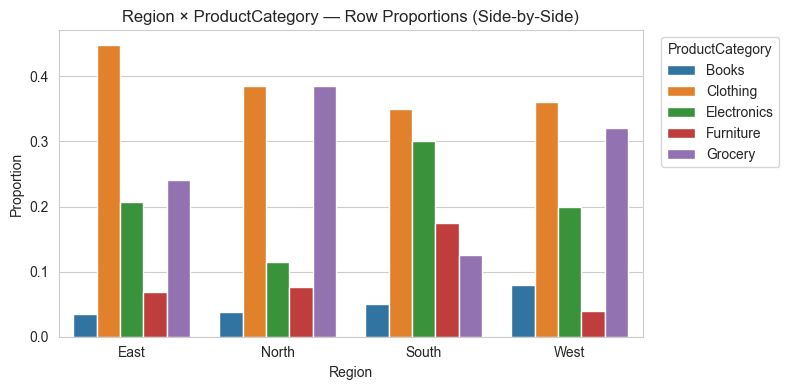

In [ ]:
ct2 = pd.crosstab(purchases["Region"], purchases["ProductCategory"])
ct2_prop = ct2.div(ct2.sum(axis=1), axis=0).reset_index().melt(id_vars="Region", var_name="ProductCategory", value_name="prop")
ax = sns.barplot(data=ct2_prop, x="Region", y="prop", hue="ProductCategory")
plt.title("Region × ProductCategory — Row Proportions (Side-by-Side)")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", title="ProductCategory")
plt.tight_layout(); plt.show()

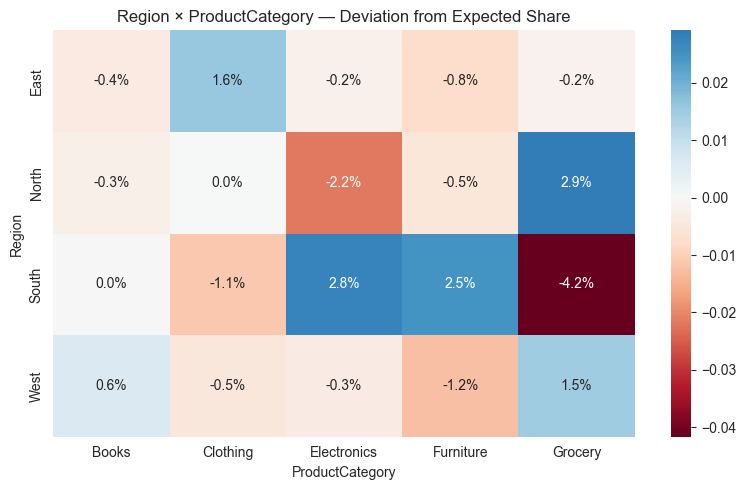

In [74]:
obs = pd.crosstab(purchases["Region"], purchases["ProductCategory"])
obs_prop = obs / obs.values.sum()
row_marg = obs.sum(axis=1); col_marg = obs.sum(axis=0)
exp = np.outer(row_marg, col_marg) / obs.values.sum()
exp = pd.DataFrame(exp, index=obs.index, columns=obs.columns)
exp_prop = exp / exp.values.sum()
dev = obs_prop - exp_prop

plt.figure(figsize=(8,5))
sns.heatmap(dev, cmap="RdBu", center=0, annot=True, fmt=".1%")
plt.title("Region × ProductCategory — Deviation from Expected Share")
plt.xlabel("ProductCategory"); plt.ylabel("Region")
plt.tight_layout(); plt.show()

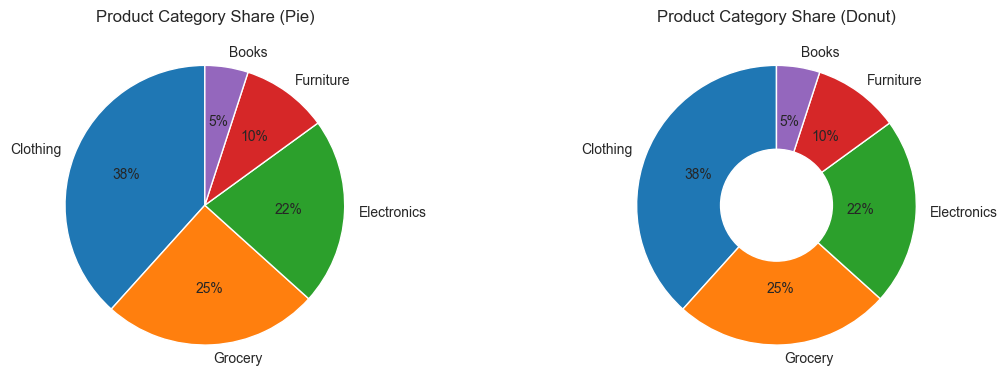

In [77]:
top5 = purchases["ProductCategory"].value_counts().nlargest(5)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].pie(top5.values, labels=top5.index, autopct="%1.0f%%", startangle=90)
ax[0].set_title("Product Category Share (Pie)")
wedges, texts, autotexts = ax[1].pie(top5.values, labels=top5.index, autopct="%1.0f%%", startangle=90)
centre_circle = plt.Circle((0,0), 0.40, fc="white")
ax[1].add_artist(centre_circle)
ax[1].set_title("Product Category Share (Donut)")
plt.tight_layout(); plt.show()